In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
application_data = pd.read_csv("IS453 Group Assignment - Application Data.csv")
bureau_data = pd.read_csv("IS453 Group Assignment - Bureau Data.csv")
print(f"IS453 Group Assignment - Application Data.csv: {application_data.shape}")
print(f"IS453 Group Assignment - Bureau Data.csv: {bureau_data.shape}")

IS453 Group Assignment - Application Data.csv: (307511, 120)
IS453 Group Assignment - Bureau Data.csv: (1716428, 17)


In [3]:
print("count of application records:", application_data["SK_ID_CURR"].count(), "unique:", application_data["SK_ID_CURR"].nunique())
print("count of bureau records:", bureau_data["SK_ID_CURR"].count(), "unique:", bureau_data["SK_ID_CURR"].nunique())
unlinked_app = set(application_data["SK_ID_CURR"]) - set(bureau_data["SK_ID_CURR"])
linked_app = set(application_data["SK_ID_CURR"]) & set(bureau_data["SK_ID_CURR"])
print("unlinked applications:", len(unlinked_app))
print("linked applications:", len(linked_app))

count of application records: 307511 unique: 307511
count of bureau records: 1716428 unique: 305811
unlinked applications: 44020
linked applications: 263491


In [4]:
# Whether applicant ever had a car loan before
bureau_data["HAS_CAR_LOAN"] = (bureau_data["CREDIT_TYPE"] == "Car loan").astype(int)

car_loan_hist = (
    bureau_data.groupby("SK_ID_CURR", as_index=False)["HAS_CAR_LOAN"]
    .max()
    .rename(columns={"HAS_CAR_LOAN": "HAS_CAR_LOAN_HISTORY"})
)

# Merge to application data
df = application_data.merge(car_loan_hist, on="SK_ID_CURR", how="left")
df["HAS_CAR_LOAN_HISTORY"] = df["HAS_CAR_LOAN_HISTORY"].fillna(0).astype(int)

# Derive helper fields
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).round(1)

# DAYS_EMPLOYED has special placeholder 365243 for missing/unknown
df["EMP_YEARS"] = (
    df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .abs() / 365.25
).round(1)


# Define Applicant Filters:
group5_filter = (
    (df["NAME_CONTRACT_TYPE"] == "Cash loans") &
    (df["FLAG_OWN_CAR"] != "Y") &
    (df["HAS_CAR_LOAN_HISTORY"] != 1) &
    (df["AGE_YEARS"].between(21, 65))
)
group5 = df[group5_filter].copy()

##at this point, drop columns "DAYS_BIRTH", "DAYS_EMPLOYED", "NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "HAS_CAR_LOAN_HISTORY" and "OWN_CAR_AGE". Drop CODE_GENDER for fairness

group5.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED","NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "HAS_CAR_LOAN_HISTORY", "OWN_CAR_AGE", "CODE_GENDER"], inplace=True)

# Comparison
original_rows = len(df)
selected_rows = len(group5)

original_bad_rate = df["TARGET"].mean()
selected_bad_rate = group5["TARGET"].mean()

print("=== GROUP 5 CHECKPOINT RESULTS ===")
print(f"Original rows: {original_rows:,}")
print(f"Selected rows: {selected_rows:,}")
print(f"Original bad rate: {original_bad_rate:.4%}")
print(f"Selected bad rate: {selected_bad_rate:.4%}")
print(f"Difference in bad rate: {(selected_bad_rate - original_bad_rate):.4%}")

# Quick profile of the selected segment
print("\n=== SEGMENT PROFILE ===")
print(group5[[
    "AGE_YEARS", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "TARGET"
]].describe())

print("\nIncome type distribution:")
print(group5["NAME_INCOME_TYPE"].value_counts(dropna=False))

print("\nFamily status distribution:")
print(group5["NAME_FAMILY_STATUS"].value_counts(dropna=False))

=== GROUP 5 CHECKPOINT RESULTS ===
Original rows: 307,511
Selected rows: 173,647
Original bad rate: 8.0729%
Selected bad rate: 9.0004%
Difference in bad rate: 0.9276%

=== SEGMENT PROFILE ===
       AGE_YEARS  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY    TARGET
count  173647.00         173647.00   173647.00    173639.00 173647.00
mean       44.65         155167.95   602028.65     26935.61      0.09
std        11.79         291860.24   382756.97     13364.39      0.29
min        21.00          25650.00    45000.00      1615.50      0.00
25%        34.80         103500.00   292500.00     17374.50      0.00
50%        44.50         135000.00   526491.00     24984.00      0.00
75%        54.90         180000.00   808650.00     33511.50      0.00
max        65.00      117000000.00  4050000.00    230161.50      1.00

Income type distribution:
NAME_INCOME_TYPE
Working                 87478
Commercial associate    37309
Pensioner               36185
State servant           12655
Student       

In [5]:
# Application Data Overview
app_missing = pd.DataFrame({
    'dtype': group5.dtypes,
    'null_count': group5.isnull().sum(),
    'null_pct': (group5.isnull().sum() / len(group5) * 100).round(2),
    'nunique': group5.nunique()
}).sort_values('null_pct', ascending=False)

print(f"Shape: {group5.shape}")
print(f"\nData types:\n{group5.dtypes.value_counts()}")

print(f"\nNumerical Summary:")
display(group5.describe())

Shape: (173647, 116)

Data types:
float64    64
int64      39
object     13
Name: count, dtype: int64

Numerical Summary:


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMP_YEARS
count,173647.00,173647.00,173647.00,173647.00,173647.00,173639.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,73634.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,86225.00,72495.00,89774.00,58178.00,52332.00,81438.00,86933.00,87978.00,55774.00,71182.00,54931.00,87261.00,52972.00,78122.00,90683.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,173647.00,148186.00,148186.00,148186.00,148186.00,148186.00,148186.00,173647.00,137453.00
mean,278124.14,0.09,0.37,155167.95,602028.65,26935.61,535027.61,0.02,-5173.83,-2995.62,1.00,0.79,0.21,1.00,0.28,0.05,2.07,2.07,2.05,12.00,0.01,0.04,0.03,0.08,0.21,0.16,0.51,0.11,0.09,0.98,0.75,0.04,0.07,0.15,0.22,0.23,0.07,0.10,0.10,0.01,0.03,0.11,0.09,0.98,0.76,0.04,0.07,0.14,0.22,0.22,0.06,0.10,0.10,0.01,0.03,0.12,0.09,0.98,0.75,0.04,0.07,0.15,0.22,0.23,0.07,0.10,0.10,0.01,0.03,0.10,1.43,0.15,1.41,0.10,-956.41,0.00,0.82,0.00,0.02,0.11,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.01,0.04,0.26,0.28,1.97,44.65,6.71
std,102748.19,0.29,0.69,291860.24,382756.97,13364.39,350949.12,0.01,3586.91,1502.46,0.00,0.41,0.40,0.02,0.45,0.22,0.89,0.51,0.50,3.27,0.12,0.21,0.18,0.27,0.41,0.37,0.21,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.10,0.11,0.05,0.07,0.11,0.08,0.06,0.11,0.07,0.13,0.10,0.14,0.16,0.08,0.09,0.11,0.05,0.07,0.10,2.33,0.45,2.31,0.37,820.15,0.01,0.39,0.01,0.12,0.31,0.00,0.19,0.07,0.00,0.06,0.00,0.01,0.05,0.01,0.10,0.02,0.09,0.02,0.02,0.00,0.08,0.11,0.21,0.89,0.92,1.90,11.79,6.70
min,100002.00,0.00,0.00,

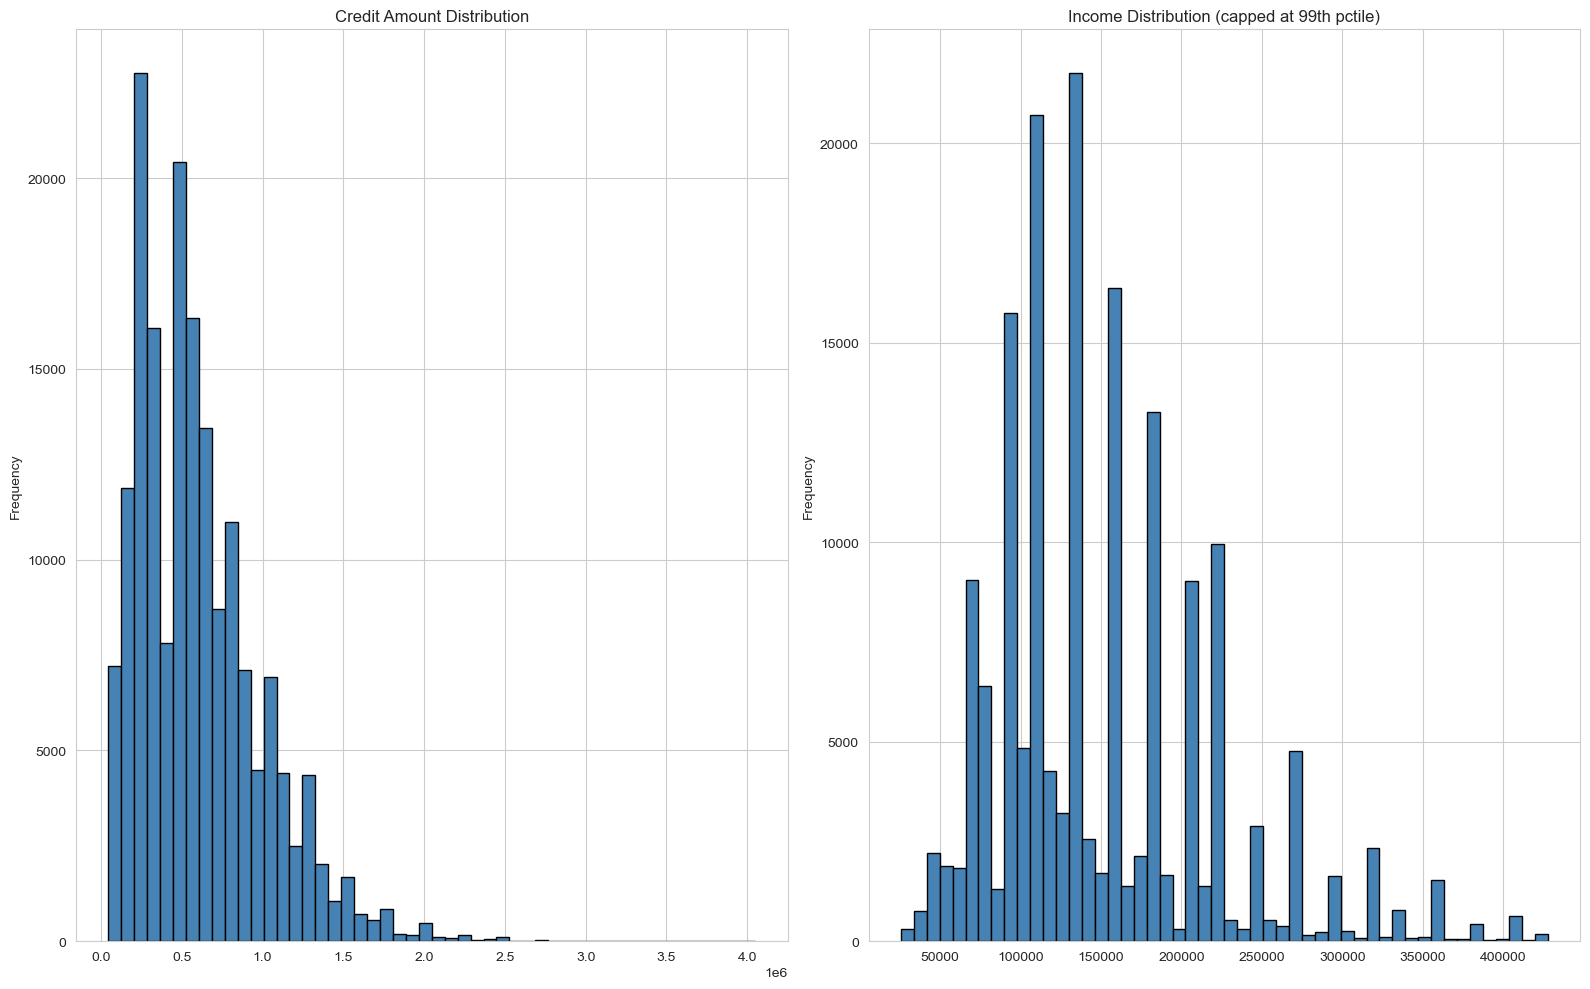

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Credit amount
group5['AMT_CREDIT'].plot(
    kind='hist', bins=50, ax=axes[0],
    color='steelblue', edgecolor='black'
)
axes[0].set_title('Credit Amount Distribution')

# Income (capped at 99th pctile for readability)
cap = group5['AMT_INCOME_TOTAL'].quantile(0.99)
group5.loc[group5['AMT_INCOME_TOTAL'] <= cap, 'AMT_INCOME_TOTAL'].plot(
    kind='hist', bins=50, ax=axes[1],
    color='steelblue', edgecolor='black'
)
axes[1].set_title('Income Distribution (capped at 99th pctile)')

plt.tight_layout()
plt.show()

In [7]:
group5.nunique().sort_values(ascending=True).head()

FLAG_DOCUMENT_10               1
FLAG_DOCUMENT_7                1
FLAG_DOCUMENT_12               1
FLAG_MOBIL                     1
LIVE_REGION_NOT_WORK_REGION    2
dtype: int64

In [8]:
##aggregate enquiry data into one column and drop the original columns
group5["TOTAL_ENQUIRIES"] = group5[[
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]].sum(axis=1)

group5.drop(columns=[ "AMT_REQ_CREDIT_BUREAU_HOUR", 
                      "AMT_REQ_CREDIT_BUREAU_DAY", 
                      "AMT_REQ_CREDIT_BUREAU_WEEK", 
                      "AMT_REQ_CREDIT_BUREAU_MON", 
                      "AMT_REQ_CREDIT_BUREAU_QRT", 
                      "AMT_REQ_CREDIT_BUREAU_YEAR"], inplace=True)

##drop the columns with no variance (only 1 unique value)
group5.drop(columns=['FLAG_DOCUMENT_12','FLAG_DOCUMENT_7','FLAG_MOBIL','FLAG_DOCUMENT_10'], inplace=True)

# Calculate missing percentage for each column
missing_pct = group5.isnull().mean()

# Identify columns with more than 45% missing
cols_to_drop = missing_pct[missing_pct > 0.45].index.tolist()

print(f"Columns to drop ({len(cols_to_drop)}):")
print(cols_to_drop)

# Drop them
group5 = group5.drop(columns=cols_to_drop)
print(f"\nShape after dropping: {group5.shape}")

Columns to drop (48):
['EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTA

In [9]:
group5.loc[:, group5.isnull().sum() > 0].isnull().sum()

##need to find out what to do with the missing data at this level before merging

# AMT_ANNUITY            8
# NAME_TYPE_SUITE      534 - leave as missing, can use binning
# OCCUPATION_TYPE    59540 - leave as missing, unemployed or pensioners
# EMP_YEARS          36194 - leave as missing, unemployed or pensioners

AMT_ANNUITY            8
NAME_TYPE_SUITE      534
OCCUPATION_TYPE    59540
EMP_YEARS          36194
dtype: int64

In [10]:
# Calculate correlation of AMT_ANNUITY with all other numeric columns
correlations = group5.corr(numeric_only=True)['AMT_ANNUITY'].sort_values(ascending=False)

# Filter out AMT_ANNUITY itself and get the top match
# We use .index[1] because .index[0] will be 'AMT_ANNUITY' (correlation = 1.0)
best_feature = correlations.index[1]
best_corr_value = correlations.values[1]

print(f"The column most correlated with AMT_ANNUITY is: {best_feature}")
print(f"Correlation coefficient: {best_corr_value:.4f}")

The column most correlated with AMT_ANNUITY is: AMT_GOODS_PRICE
Correlation coefficient: 0.7658


In [11]:
# 1. Calculate the median ratio between Annuity and the best feature
# (Using median is safer than mean to avoid outlier distortion)
valid_data = group5[group5['AMT_ANNUITY'].notnull() & group5[best_feature].notnull()]
median_ratio = (valid_data['AMT_ANNUITY'] / valid_data[best_feature]).median()

print(f"Median ratio (Annuity / {best_feature}): {median_ratio:.4f}")

# 2. Identify rows where Annuity is missing but the anchor feature exists
mask = group5['AMT_ANNUITY'].isnull() & group5[best_feature].notnull()

# 3. Fill missing values using the ratio
group5.loc[mask, 'AMT_ANNUITY'] = group5.loc[mask, best_feature] * median_ratio

# 4. Final fallback: If both are missing, use the global median of AMT_ANNUITY
group5['AMT_ANNUITY'] = group5['AMT_ANNUITY'].fillna(group5['AMT_ANNUITY'].median())

print(f"Remaining NaNs in AMT_ANNUITY: {group5['AMT_ANNUITY'].isnull().sum()}")

Median ratio (Annuity / AMT_GOODS_PRICE): 0.0542
Remaining NaNs in AMT_ANNUITY: 0


In [12]:
# Categorical variables — distribution & bad-rate
cat_cols = group5.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    vc = group5[col].value_counts(dropna=False)
    bad_rate = group5.groupby(col, dropna=False)['TARGET'].mean()
    summary = pd.DataFrame({
        'count': vc,
        'pct': (vc / len(group5) * 100).round(2),
        'bad_rate': bad_rate
    }).sort_values('count', ascending=False)
    summary['bad_rate'] = summary['bad_rate'].apply(
        lambda x: f"{x:.2%}" if pd.notna(x) else "N/A")
    print(f"--- {col}  ({group5[col].nunique()} unique, "
          f"{group5[col].isnull().sum()} nulls) ---")
    display(summary.head(10))
    print()

Categorical columns (9): ['FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

--- FLAG_OWN_REALTY  (2 unique, 0 nulls) ---


,count,pct,bad_rate
FLAG_OWN_REALTY,,,
Y,118463,68.22,8.80%
N,55184,31.78,9.42%



--- NAME_TYPE_SUITE  (7 unique, 534 nulls) ---


,count,pct,bad_rate
NAME_TYPE_SUITE,,,
Unaccompanied,140604,80.97,9.15%
Family,22888,13.18,8.14%
"Spouse, partner",5754,3.31,8.99%
Children,2101,1.21,8.14%
Other_B,1108,0.64,10.83%
NaN,534,0.31,5.62%
Other_A,500,0.29,9.00%
Group of people,158,0.09,9.49%



--- NAME_INCOME_TYPE  (7 unique, 0 nulls) ---


...

,count,pct,bad_rate
OCCUPATION_TYPE,,,
NaN,59540,34.29,7.08%
Laborers,29739,17.13,12.32%
Sales staff,20474,11.79,10.59%
Core staff,16005,9.22,7.20%
Managers,8426,4.85,7.31%
High skill tech staff,5971,3.44,7.29%
Medicine staff,5852,3.37,7.16%
Accountants,5360,3.09,5.52%
Drivers,5060,2.91,14.76%



--- WEEKDAY_APPR_PROCESS_START  (7 unique, 0 nulls) ---


,count,pct,bad_rate
WEEKDAY_APPR_PROCESS_START,,,
TUESDAY,30757,17.71,9.26%
WEDNESDAY,29210,16.82,9.18%
MONDAY,28671,16.51,8.52%
FRIDAY,28355,16.33,9.18%
THURSDAY,28296,16.30,8.93%
SATURDAY,19273,11.10,8.89%
SUNDAY,9085,5.23,8.93%



--- ORGANIZATION_TYPE  (58 unique, 0 nulls) ---


,count,pct,bad_rate
ORGANIZATION_TYPE,,,
XNA,36194,20.84,5.92%
Business Entity Type 3,35048,20.18,10.82%
Self-employed,20917,12.05,11.36%
Other,9379,5.40,8.53%
Medicine,7253,4.18,7.18%
Government,6074,3.50,8.05%
School,5724,3.30,6.31%
Business Entity Type 2,5701,3.28,9.31%
Kindergarten,4824,2.78,7.86%


Shape: (1716428, 18)

Data types:
float64    8
int64      6
object     3
int32      1
Name: count, dtype: int64

Missing Values:


,dtype,null_count,null_pct,nunique
AMT_ANNUITY,float64,1226791,71.47,40321
AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.51,68251
DAYS_ENDDATE_FACT,float64,633653,36.92,2917
AMT_CREDIT_SUM_LIMIT,float64,591780,34.48,51726
AMT_CREDIT_SUM_DEBT,float64,257669,15.01,226537
DAYS_CREDIT_ENDDATE,float64,105553,6.15,14096
SK_ID_CURR,int64,0,0.00,305811
DAYS_CREDIT_UPDATE,int64,0,0.00,2982
CREDIT_TYPE,object,0,0.00,15
AMT_CREDIT_SUM_OVERDUE,float64,0,0.00,1616


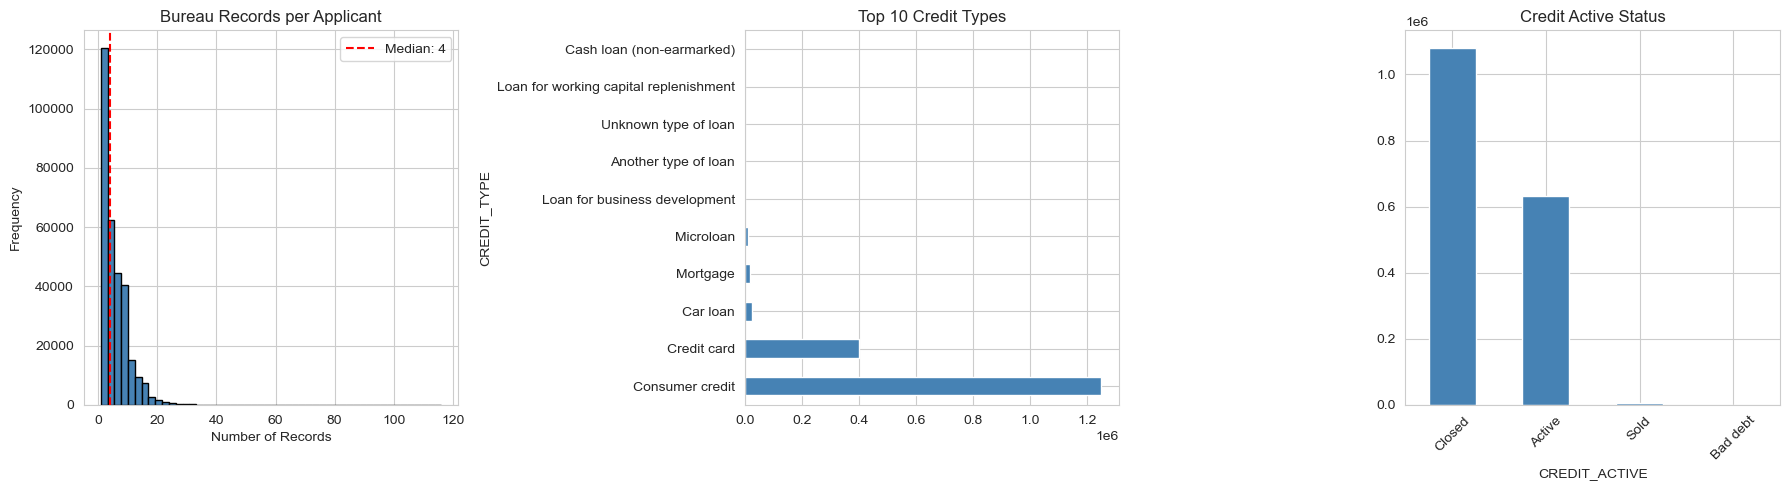


Records per applicant:
count   305811.00
mean         5.61
std          4.43
min          1.00
25%          2.00
50%          4.00
75%          8.00
max        116.00
dtype: float64

Bureau Numerical Summary:


,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,HAS_CAR_LOAN
count,1716428.00,1716428.00,1716428.00,1716428.00,1610875.00,1082775.00,591940.00,1716428.00,1716415.00,1458759.00,1124648.00,1716428.00,1716428.00,489637.00,1716428.00
mean,278214.93,5924434.49,-1142.11,0.82,510.52,-1017.44,3825.42,0.01,354994.59,137085.12,6229.51,37.91,-593.75,15712.76,0.02
std,102938.56,532265.73,795.16,36.54,4994.22,714.01,206031.61,0.10,1149811.34,677401.13,45032.03,5937.65,720.75,325826.95,0.13
min,100001.00,5000000.00,-2922.00,0.00,-42060.00,-42023.00,0.00,0.00,0.00,-4705600.32,-586406.11,0.00,-41947.00,0.00,0.00
25%,188866.75,5463953.75,-1666.00,0.00,-1138.00,-1489.00,0.00,0.00,51300.00,0.00,0.00,0.00,-908.00,0.00,0.00
50%,278055.00,5926303.50,-987.00,0.00,-330.00,-897.00,0.00,0.00,125518.50,0.00,0.00,0.00,-395.00,0.00,0.00
75%,367426.00,6385681.25,-474.00,0.00,474.00,-425.00,0.00,0.00,315000.00,40153.50,0.00,0.00,-33.00,13500.00,0.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,372.00,118453423.50,1.00


In [13]:
# Bureau Data Overview
bureau_missing = pd.DataFrame({
    'dtype': bureau_data.dtypes,
    'null_count': bureau_data.isnull().sum(),
    'null_pct': (bureau_data.isnull().sum() / len(bureau_data) * 100).round(2),
    'nunique': bureau_data.nunique()
}).sort_values('null_pct', ascending=False)

print(f"Shape: {bureau_data.shape}")
print(f"\nData types:\n{bureau_data.dtypes.value_counts()}")
print(f"\nMissing Values:")
display(bureau_missing)

# Distributions
records_per_app = bureau_data.groupby('SK_ID_CURR').size()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

records_per_app.plot(kind='hist', bins=50, ax=axes[0],
                     color='steelblue', edgecolor='black')
axes[0].set_title('Bureau Records per Applicant')
axes[0].set_xlabel('Number of Records')
axes[0].axvline(records_per_app.median(), color='red', linestyle='--',
                label=f'Median: {records_per_app.median():.0f}')
axes[0].legend()

bureau_data['CREDIT_TYPE'].value_counts().head(10).plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Credit Types')

bureau_data['CREDIT_ACTIVE'].value_counts().plot(
    kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Credit Active Status')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nRecords per applicant:\n{records_per_app.describe()}")
print(f"\nBureau Numerical Summary:")
display(bureau_data.describe())

In [14]:
bureau_data['DAYS_CREDIT_ENDDATE'] = np.where(
    bureau_data['DAYS_CREDIT_ENDDATE'] < -16294,
    np.nan,
    bureau_data['DAYS_CREDIT_ENDDATE']
)
bureau_data['DAYS_ENDDATE_FACT'] = np.where(
    bureau_data['DAYS_ENDDATE_FACT'] < -42022,
    np.nan,
    bureau_data['DAYS_ENDDATE_FACT']
)
bureau_data['DAYS_CREDIT_UPDATE'] = np.where(
    bureau_data['DAYS_CREDIT_UPDATE'] < -41850,
    np.nan,
    bureau_data['DAYS_CREDIT_UPDATE']
)

##0.49% of AMT_CREDIT_SUM_DEBT values are below 0. This is likely due to overpayment or credit balance. Since we will be doing sums and averages later, we can ignore this for now and floor at 0 after aggregation.
##0.02% of AMT_CREDIT_SUM_LIMIT are below 0, which is likely data error. We can set these to NaN as well. we can change this later.
bureau_data['AMT_CREDIT_SUM_LIMIT'] = np.where(
    bureau_data['AMT_CREDIT_SUM_LIMIT'] < 0,
    np.nan,
    bureau_data['AMT_CREDIT_SUM_LIMIT']
)

In [15]:
bureau_data.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,HAS_CAR_LOAN
count,1716428.00,1716428.00,1716428.00,1716428.00,1610729.00,1082774.00,591940.00,1716428.00,1716415.00,1458759.00,1124297.00,1716428.00,1716333.00,489637.00,1716428.00
mean,278214.93,5924434.49,-1142.11,0.82,514.17,-1017.40,3825.42,0.01,354994.59,137085.12,6238.88,37.91,-591.46,15712.76,0.02
std,102938.56,532265.73,795.16,36.54,4979.26,712.92,206031.61,0.10,1149811.34,677401.13,45022.33,5937.65,651.99,325826.95,0.13
min,100001.00,5000000.00,-2922.00,0.00,-5150.00,-3042.00,0.00,0.00,0.00,-4705600.32,0.00,0.00,-2917.00,0.00,0.00
25%,188866.75,5463953.75,-1666.00,0.00,-1137.00,-1489.00,0.00,0.00,51300.00,0.00,0.00,0.00,-908.00,0.00,0.00
50%,278055.00,5926303.50,-987.00,0.00,-330.00,-897.00,0.00,0.00,125518.50,0.00,0.00,0.00,-395.00,0.00,0.00
75%,367426.00,6385681.25,-474.00,0.00,474.00,-425.00,0.00,0.00,315000.00,40153.50,0.00,0.00,-33.00,13500.00,0.00
max,456255.00,6843457.00,0.00,2792.00,31199.00,0.00,115987185.00,9.00,585000000.00,170100000.00,4705600.32,3756681.00,372.00,118453423.50,1.00


In [16]:
# ── Binary flags before aggregation ──
bureau_data['BUREAU_IS_ACTIVE']   = (bureau_data['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_data['BUREAU_IS_CLOSED']   = (bureau_data['CREDIT_ACTIVE'] == 'Closed').astype(int)
bureau_data['BUREAU_IS_BAD_SOLD'] = (bureau_data['CREDIT_ACTIVE'].isin(['Sold', 'Bad debt'])).astype(int)

# ── Collapse rare credit types ──
top_types = ['Consumer credit', 'Credit card', 'Car loan', 'Mortgage', 'Microloan']
bureau_data['CREDIT_TYPE_GROUPED'] = bureau_data['CREDIT_TYPE'].apply(
    lambda x: x if x in top_types else 'Other'
)

# ── Main aggregation ──
bureau_agg = bureau_data.groupby('SK_ID_CURR').agg(
    # ── Record count ──
    BUREAU_RECORD_COUNT        = ('SK_ID_BUREAU', 'count'),

    # ── Credit active status ──
    BUREAU_ACTIVE_COUNT        = ('BUREAU_IS_ACTIVE', 'sum'),
    BUREAU_CLOSED_COUNT        = ('BUREAU_IS_CLOSED', 'sum'),
    BUREAU_BAD_SOLD_COUNT      = ('BUREAU_IS_BAD_SOLD', 'sum'),  # strong risk signal

    # ── Days credit (when credit was reported, negative = past) ──
    BUREAU_OLDEST_CREDIT       = ('DAYS_CREDIT', 'min'),   # most negative = oldest
    BUREAU_RECENT_CREDIT       = ('DAYS_CREDIT', 'max'),   # closest to 0 = most recent
    BUREAU_AVG_CREDIT_AGE      = ('DAYS_CREDIT', 'mean'),

    # ── Days overdue ──
    BUREAU_MAX_OVERDUE_DAYS    = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MEAN_OVERDUE_DAYS   = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_SUM_OVERDUE_DAYS    = ('CREDIT_DAY_OVERDUE', 'sum'),

    # ── Credit end date ──
    BUREAU_EARLIEST_ENDDATE    = ('DAYS_CREDIT_ENDDATE', 'min'),
    BUREAU_LATEST_ENDDATE      = ('DAYS_CREDIT_ENDDATE', 'max'),

    # ── Actual end date (only for closed credits) ──
    BUREAU_EARLIEST_CLOSED     = ('DAYS_ENDDATE_FACT', 'min'),
    BUREAU_LATEST_CLOSED       = ('DAYS_ENDDATE_FACT', 'max'),

    # ── Max overdue amount ever ──
    BUREAU_MAX_AMT_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_MEAN_AMT_OVERDUE    = ('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_SUM_AMT_OVERDUE     = ('AMT_CREDIT_MAX_OVERDUE', 'sum'),

    # ── Credit prolongations ──
    BUREAU_TOTAL_PROLONGATIONS = ('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_MAX_PROLONGATIONS   = ('CNT_CREDIT_PROLONG', 'max'),

    # ── Total credit amount ──
    BUREAU_TOTAL_CREDIT        = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_MAX_CREDIT          = ('AMT_CREDIT_SUM', 'max'),
    BUREAU_MEAN_CREDIT         = ('AMT_CREDIT_SUM', 'mean'),

    # ── Outstanding debt ──
    BUREAU_TOTAL_DEBT          = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_MAX_DEBT            = ('AMT_CREDIT_SUM_DEBT', 'max'),
    BUREAU_MEAN_DEBT           = ('AMT_CREDIT_SUM_DEBT', 'mean'),

    # ── Credit limit ──
    BUREAU_TOTAL_LIMIT         = ('AMT_CREDIT_SUM_LIMIT', 'sum'),
    BUREAU_MAX_LIMIT           = ('AMT_CREDIT_SUM_LIMIT', 'max'),

    # ── Current overdue amount ──
    BUREAU_TOTAL_AMT_OVERDUE   = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_MAX_AMT_OVERDUE_NOW = ('AMT_CREDIT_SUM_OVERDUE', 'max'),

    # ── Credit type diversity ──
    BUREAU_CREDIT_TYPE_COUNT   = ('CREDIT_TYPE_GROUPED', 'nunique'),

    # ── Days since last update ──
    BUREAU_LAST_UPDATE         = ('DAYS_CREDIT_UPDATE', 'max'),
    BUREAU_OLDEST_UPDATE       = ('DAYS_CREDIT_UPDATE', 'min'),

    # ── Annuity ──
    BUREAU_TOTAL_ANNUITY       = ('AMT_ANNUITY', 'sum'),
    BUREAU_MAX_ANNUITY         = ('AMT_ANNUITY', 'max'),
    BUREAU_MEAN_ANNUITY        = ('AMT_ANNUITY', 'mean'),
).reset_index()

# ── Credit type pivot (collapsed) ──
credit_type_pivot = bureau_data.groupby('SK_ID_CURR')['CREDIT_TYPE_GROUPED'] \
    .value_counts().unstack(fill_value=0)
credit_type_pivot.columns = [
    f'BUREAU_TYPE_{c.replace(" ", "_").upper()}'
    for c in credit_type_pivot.columns]

# ── Final merge ──
bureau_agg = bureau_agg \
    .merge(credit_type_pivot.reset_index(), on='SK_ID_CURR', how='left')
# All zero-fills
fill_zero = [
    'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_MEAN_AMT_OVERDUE',
    'BUREAU_MAX_DEBT', 'BUREAU_MEAN_DEBT',
    'BUREAU_MAX_LIMIT', 'BUREAU_MAX_ANNUITY', 'BUREAU_MEAN_ANNUITY',
    'BUREAU_MAX_CREDIT', 'BUREAU_MEAN_CREDIT',
]
bureau_agg[fill_zero] = bureau_agg[fill_zero].fillna(0)

# Conditional — flag then fill
bureau_agg['HAS_NO_CLOSED_CREDIT'] = bureau_agg['BUREAU_EARLIEST_CLOSED'].isna().astype(int)
bureau_agg['HAS_NO_ENDDATE']        = bureau_agg['BUREAU_EARLIEST_ENDDATE'].isna().astype(int)

bureau_agg.drop("BUREAU_TYPE_CAR_LOAN", axis=1, inplace=True)
print(f"Bureau aggregated shape: {bureau_agg.shape}")
print(f"Columns: {bureau_agg.columns.tolist()}")

Bureau aggregated shape: (305811, 43)
Columns: ['SK_ID_CURR', 'BUREAU_RECORD_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_CLOSED_COUNT', 'BUREAU_BAD_SOLD_COUNT', 'BUREAU_OLDEST_CREDIT', 'BUREAU_RECENT_CREDIT', 'BUREAU_AVG_CREDIT_AGE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MEAN_OVERDUE_DAYS', 'BUREAU_SUM_OVERDUE_DAYS', 'BUREAU_EARLIEST_ENDDATE', 'BUREAU_LATEST_ENDDATE', 'BUREAU_EARLIEST_CLOSED', 'BUREAU_LATEST_CLOSED', 'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_MEAN_AMT_OVERDUE', 'BUREAU_SUM_AMT_OVERDUE', 'BUREAU_TOTAL_PROLONGATIONS', 'BUREAU_MAX_PROLONGATIONS', 'BUREAU_TOTAL_CREDIT', 'BUREAU_MAX_CREDIT', 'BUREAU_MEAN_CREDIT', 'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_DEBT', 'BUREAU_MEAN_DEBT', 'BUREAU_TOTAL_LIMIT', 'BUREAU_MAX_LIMIT', 'BUREAU_TOTAL_AMT_OVERDUE', 'BUREAU_MAX_AMT_OVERDUE_NOW', 'BUREAU_CREDIT_TYPE_COUNT', 'BUREAU_LAST_UPDATE', 'BUREAU_OLDEST_UPDATE', 'BUREAU_TOTAL_ANNUITY', 'BUREAU_MAX_ANNUITY', 'BUREAU_MEAN_ANNUITY', 'BUREAU_TYPE_CONSUMER_CREDIT', 'BUREAU_TYPE_CREDIT_CARD', 'BUREAU_TYPE_MICROLOAN'

In [17]:
##create new features based on bureau data
# 1. Bureau Credit Utilisation  (outstanding debt / total credit limit)
#    Core credit-scoring signal — 90% utilisation >> 30% at same absolute debt
bureau_agg['BUREAU_DEBT_UTIL'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / bureau_agg['BUREAU_TOTAL_LIMIT']
).clip(lower=0, upper=5)   # floor at 0 (debt already floored) + cap extreme outliers


# 2. Average Prolongations per Bureau Loan  (habitual extension frequency)
bureau_agg['BUREAU_AVG_PROLONGATIONS'] = (
    bureau_agg['BUREAU_TOTAL_PROLONGATIONS']
    / bureau_agg['BUREAU_RECORD_COUNT']
)

# 3. Bureau Active Rate  (fraction of credits still active)
#    RECORD_COUNT = ACTIVE + CLOSED + BAD_SOLD is a mathematical identity →
#    keeping all three causes VIF in the thousands. Convert to rate instead.
bureau_agg['BUREAU_ACTIVE_RATE'] = (
    bureau_agg['BUREAU_ACTIVE_COUNT']
    / bureau_agg['BUREAU_RECORD_COUNT']
)

# 4. Bureau Bad/Sold Rate  (fraction of credits written off or sold)
bureau_agg['BUREAU_BAD_SOLD_RATE'] = (
    bureau_agg['BUREAU_BAD_SOLD_COUNT']
    / bureau_agg['BUREAU_RECORD_COUNT']
)


In [18]:
merged_df = group5.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"\nMerged DataFrame: {merged_df.shape}")
print(f"With bureau data:    {merged_df['BUREAU_RECORD_COUNT'].notna().sum():,}")
print(f"Without bureau data: {merged_df['BUREAU_RECORD_COUNT'].isna().sum():,}")


Merged DataFrame: (173647, 105)
With bureau data:    146,768
Without bureau data: 26,879


In [19]:
merged_missing = pd.DataFrame({
    'dtype': merged_df.dtypes,
    'null_count': merged_df.isnull().sum(),
    'null_pct': (merged_df.isnull().sum() / len(merged_df) * 100).round(2),
    'nunique': merged_df.nunique()
}).sort_values('null_pct', ascending=False)


print(f"\nData types:\n{merged_df.dtypes.value_counts()}")
print(f"\nMissing Values:")
pd.set_option('display.max_rows', None)
display(merged_missing[merged_missing["null_count"]>0].sort_values("null_count", ascending=False))



Data types:
float64    61
int64      35
object      9
Name: count, dtype: int64

Missing Values:


,dtype,null_count,null_pct,nunique
BUREAU_DEBT_UTIL,float64,68849,39.65,9397
OCCUPATION_TYPE,object,59540,34.29,18
BUREAU_LATEST_CLOSED,float64,45964,26.47,2771
BUREAU_EARLIEST_CLOSED,float64,45964,26.47,2892
EMP_YEARS,float64,36194,20.84,453
BUREAU_EARLIEST_ENDDATE,float64,28171,16.22,5963
BUREAU_LATEST_ENDDATE,float64,28171,16.22,11350
BUREAU_OLDEST_UPDATE,float64,26880,15.48,2887
BUREAU_LAST_UPDATE,float64,26880,15.48,2530
BUREAU_MAX_LIMIT,float64,26879,15.48,19502


In [21]:
# Select numerical columns for VIF
vif_candidates = merged_df.select_dtypes(include='number').columns.tolist()
vif_candidates = [c for c in vif_candidates
                  if c not in ['SK_ID_CURR', 'TARGET']
                  and merged_df[c].nunique() > 1]

# Use top-30 by TARGET correlation (VIF is O(p²n))
target_corr_abs = merged_df[vif_candidates + ['TARGET']].corr()['TARGET'] \
    .drop('TARGET').abs().sort_values(ascending=False)
vif_candidates = target_corr_abs.head(30).index.tolist()
print(f"VIF on top 30 features (by |corr with TARGET|)")

# Sample for speed & standardise
sample = merged_df[vif_candidates].sample(
    min(10_000, len(merged_df)), random_state=42).dropna()
sample_std = (sample - sample.mean()) / sample.std()
sample_std = sample_std.dropna(axis=1)           # drop any all-NaN cols

vif_results = pd.DataFrame({
    'feature': sample_std.columns,
    'VIF': [variance_inflation_factor(sample_std.values, i)
            for i in range(sample_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF  (>5 = moderate,  >10 = severe multicollinearity)")
display(vif_results)

high_vif = vif_results[vif_results['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

VIF on top 30 features (by |corr with TARGET|)

VIF  (>5 = moderate,  >10 = severe multicollinearity)


,feature,VIF
22,AMT_CREDIT,36.47
16,AMT_GOODS_PRICE,36.39
10,REGION_RATING_CLIENT_W_CITY,10.60
11,REGION_RATING_CLIENT,10.56
0,BUREAU_AVG_CREDIT_AGE,9.72
9,BUREAU_EARLIEST_CLOSED,8.50
4,BUREAU_OLDEST_CREDIT,8.47
7,REG_CITY_NOT_WORK_CITY,8.23
17,LIVE_CITY_NOT_WORK_CITY,6.56
5,BUREAU_ACTIVE_COUNT,4.58



Features with VIF > 5: 9


,feature,VIF
22,AMT_CREDIT,36.47
16,AMT_GOODS_PRICE,36.39
10,REGION_RATING_CLIENT_W_CITY,10.60
11,REGION_RATING_CLIENT,10.56
0,BUREAU_AVG_CREDIT_AGE,9.72
9,BUREAU_EARLIEST_CLOSED,8.50
4,BUREAU_OLDEST_CREDIT,8.47
7,REG_CITY_NOT_WORK_CITY,8.23
17,LIVE_CITY_NOT_WORK_CITY,6.56


In [22]:
# Correlation analysis on GROUP 5 data
num_cols = merged_df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

corr_matrix = merged_df[num_cols].corr()

# 1) Correlation with TARGET
target_corr = corr_matrix['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 20 features correlated with TARGET:")
display(target_corr.head(20))

Top 20 features correlated with TARGET:


BUREAU_AVG_CREDIT_AGE         0.09
AGE_YEARS                     0.09
BUREAU_ACTIVE_RATE            0.08
EMP_YEARS                     0.08
BUREAU_OLDEST_CREDIT          0.08
BUREAU_ACTIVE_COUNT           0.07
BUREAU_OLDEST_UPDATE          0.07
REG_CITY_NOT_WORK_CITY        0.06
DAYS_LAST_PHONE_CHANGE        0.06
BUREAU_EARLIEST_CLOSED        0.06
REGION_RATING_CLIENT_W_CITY   0.06
REGION_RATING_CLIENT          0.06
DAYS_ID_PUBLISH               0.06
FLAG_EMP_PHONE                0.06
HAS_NO_CLOSED_CREDIT          0.05
BUREAU_RECENT_CREDIT          0.05
REG_CITY_NOT_LIVE_CITY        0.05
DAYS_REGISTRATION             0.05
AMT_GOODS_PRICE               0.04
LIVE_CITY_NOT_WORK_CITY       0.04
Name: TARGET, dtype: float64

In [23]:
# 2) Highly-correlated feature pairs (|r| > 0.75)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, idx, upper_tri.loc[idx, col])
    for col in upper_tri.columns for idx in upper_tri.index
    if abs(upper_tri.loc[idx, col]) > 0.75
]
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nHighly correlated feature pairs (|r| > 0.75): {len(high_corr_pairs)}")
high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=['Feature_1', 'Feature_2', 'Correlation'])
display(high_corr_df)


Highly correlated feature pairs (|r| > 0.75): 32


,Feature_1,Feature_2,Correlation
0,BUREAU_SUM_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,1.00
1,OBS_60_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,1.00
2,BUREAU_MAX_PROLONGATIONS,BUREAU_TOTAL_PROLONGATIONS,0.99
3,BUREAU_SUM_OVERDUE_DAYS,BUREAU_MAX_OVERDUE_DAYS,0.99
4,AMT_GOODS_PRICE,AMT_CREDIT,0.99
5,BUREAU_MAX_DEBT,BUREAU_TOTAL_DEBT,0.97
6,BUREAU_MEAN_AMT_OVERDUE,BUREAU_MAX_AMT_OVERDUE,0.97
7,BUREAU_SUM_AMT_OVERDUE,BUREAU_MEAN_AMT_OVERDUE,0.96
8,BUREAU_MAX_LIMIT,BUREAU_TOTAL_LIMIT,0.96
9,BUREAU_MAX_AMT_OVERDUE_NOW,BUREAU_TOTAL_AMT_OVERDUE,0.95


In [24]:
list(high_corr_df["Feature_1"]) + list(high_corr_df["Feature_2"])

['BUREAU_SUM_AMT_OVERDUE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'BUREAU_MAX_PROLONGATIONS',
 'BUREAU_SUM_OVERDUE_DAYS',
 'AMT_GOODS_PRICE',
 'BUREAU_MAX_DEBT',
 'BUREAU_MEAN_AMT_OVERDUE',
 'BUREAU_SUM_AMT_OVERDUE',
 'BUREAU_MAX_LIMIT',
 'BUREAU_MAX_AMT_OVERDUE_NOW',
 'REGION_RATING_CLIENT_W_CITY',
 'BUREAU_TYPE_CONSUMER_CREDIT',
 'BUREAU_MAX_ANNUITY',
 'BUREAU_CLOSED_COUNT',
 'BUREAU_TYPE_CONSUMER_CREDIT',
 'BUREAU_EARLIEST_CLOSED',
 'BUREAU_OLDEST_UPDATE',
 'CNT_FAM_MEMBERS',
 'BUREAU_MAX_CREDIT',
 'DEF_60_CNT_SOCIAL_CIRCLE',
 'LIVE_REGION_NOT_WORK_REGION',
 'BUREAU_OLDEST_UPDATE',
 'LIVE_CITY_NOT_WORK_CITY',
 'BUREAU_AVG_CREDIT_AGE',
 'BUREAU_MEAN_ANNUITY',
 'BUREAU_MEAN_CREDIT',
 'AMT_GOODS_PRICE',
 'BUREAU_MEAN_OVERDUE_DAYS',
 'BUREAU_MAX_DEBT',
 'AMT_ANNUITY',
 'BUREAU_MEAN_DEBT',
 'BUREAU_SUM_OVERDUE_DAYS',
 'BUREAU_MAX_AMT_OVERDUE',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'BUREAU_TOTAL_PROLONGATIONS',
 'BUREAU_MAX_OVERDUE_DAYS',
 'AMT_CREDIT',
 'BUREAU_TOTAL_DEBT',
 'BUREAU_MAX_AMT_OVERDUE',
 'B

In [25]:
import pandas as pd
import numpy as np
import scorecardpy as sc
import warnings

# 1. Feature Selection & Data Preparation
# Exclude identifiers and the target itself
target = 'TARGET'
feature_cols = list(set(list(high_corr_df["Feature_1"]) + list(high_corr_df["Feature_2"])))

# Prepare data: Ensure 'Missing' is treated as NaN for scorecardpy to handle specifically
df_processed = merged_df[feature_cols + [target]].copy()
df_processed = df_processed.replace('Missing', np.nan)

# 2. Target Distribution Check
goods = (df_processed[target] == 0).sum()
bads = (df_processed[target] == 1).sum()
print(f"Dataset Summary:")
print(f"  - Goods: {goods:,} | Bads: {bads:,} | Bad Rate: {bads/len(df_processed):.2%}")

# 3. Perform Fine Classing (WOE Binning)
print("\n" + "="*50)
print("PERFORMING FINE CLASSING (Minimum 10 Bins)")
print("="*50)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # sc.woebin automatically detects numeric vs categorical
    bins = sc.woebin(
        df_processed, 
        y=target,
        min_num_bins=10,       # Force fine granularity
        stop_limit=0.0001,     # Smallest IV gain to keep splitting
        count_distr_limit=0.02, # Allow bins as small as 2% of total
        bin_num_limit=50,      # Max upper limit
        positive='bad|1'       # Ensure it knows 1 is the default/event
    )

# 4. Extract IV Summary
# scorecardpy stores total IV for each variable within the 'binning' dataframe
iv_list = []
for var, df_bin in bins.items():
    # 'total_iv' is a constant value across all rows for a specific variable
    iv_val = df_bin['total_iv'].iloc[0]
    iv_list.append({'Variable': var, 'IV': iv_val, 'Bins': len(df_bin)})

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False)

print("\nVariable IV Summary:")
display(iv_df.head(30))

Dataset Summary:
  - Goods: 158,018 | Bads: 15,629 | Bad Rate: 9.00%

PERFORMING FINE CLASSING (Minimum 10 Bins)
[INFO] creating woe binning ...
Binning on 173647 rows and 44 columns in 00:01:40

Variable IV Summary:


,Variable,IV,Bins
38,BUREAU_AVG_CREDIT_AGE,0.13,22
9,BUREAU_OLDEST_CREDIT,0.08,25
0,BUREAU_EARLIEST_CLOSED,0.07,25
18,BUREAU_OLDEST_UPDATE,0.07,22
7,AMT_GOODS_PRICE,0.06,15
15,AMT_CREDIT,0.06,23
22,BUREAU_MEAN_DEBT,0.06,14
17,BUREAU_CLOSED_COUNT,0.05,12
24,REGION_RATING_CLIENT_W_CITY,0.05,3
39,REGION_RATING_CLIENT,0.04,3


In [26]:
merged_df["ORGANIZATION_TYPE"].nunique()  ###have to exclude this column because of too many unique values for the time being.

58

In [27]:
##create new features based on domain knowledge and correlation analysis
merged_df['LTV_RATIO'] = merged_df['AMT_CREDIT'] / merged_df['AMT_GOODS_PRICE']

# 1. Annuity-to-Income Ratio  (affordability — primary default driver)
merged_df['ANNUITY_INCOME_RATIO'] = merged_df['AMT_ANNUITY'] / merged_df['AMT_INCOME_TOTAL'] ##not very correlated

# 2. Debt-to-Annuity  (implied loan tenure in months)
merged_df['DEBT_TO_ANNUITY'] = merged_df['AMT_CREDIT'] / merged_df['AMT_ANNUITY'] 

# Total Debt Service Ratio  (all bureau repayments + new loan vs income)
# merged_df['TOTAL_DSR'] = (
#     merged_df['BUREAU_TOTAL_ANNUITY'].fillna(0) + merged_df['AMT_ANNUITY']
# ) / merged_df['AMT_INCOME_TOTAL']
#commented out because near 0 IV

# 3. Social-Circle Default Rate — 60 DPD threshold
#    OBS_30/OBS_60 are DPD severity thresholds (30+ and 60+ days past due),
#    NOT time windows. r=1.00 between OBS_30 and OBS_60 is because they measure
#    the same social circle size; only the default threshold differs.
#    DEF_60 < DEF_30 is expected (stricter threshold = fewer defaults).
merged_df['DEF_RATE_60'] = (
    merged_df['DEF_60_CNT_SOCIAL_CIRCLE']
    / merged_df['OBS_60_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
).fillna(0)

# 4. Social-Circle Default Rate — 30 DPD threshold
#    DEF_30 and DEF_60 have r=0.86 (not 1.00), so the 30 DPD rate carries
#    ~26% independent signal that would otherwise be discarded.
# merged_df['DEF_RATE_30'] = (
#     merged_df['DEF_30_CNT_SOCIAL_CIRCLE']
#     / merged_df['OBS_30_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
# ).fillna(0) 
#commented out because lower IV

## 5. Bureau Credit Card Rate  (fraction of bureau credits that are credit cards)
merged_df['BUREAU_CONSUMER_CREDIT_RATE'] = (
    merged_df['BUREAU_TYPE_CONSUMER_CREDIT'] / merged_df['BUREAU_RECORD_COUNT']
)


In [28]:
features_to_drop_after_vif= []

In [29]:
##0th pair multicollinearity - BUREAU_SUM_AMOUNT_OVERDUE vs BUREAU_MAX_AMT_OVERDUE. retain max amount overdue since it has higher iv

features_to_drop_after_vif.append("BUREAU_SUM_OVERDUE_DAYS")

#first pair - OBS_60_CNT_SOCIAL_CIRCLE	vs OBS_30_CNT_SOCIAL_CIRCLE. drop both, replace with def_60 and def_30

features_to_drop_after_vif.append("OBS_60_CNT_SOCIAL_CIRCLE")
features_to_drop_after_vif.append("OBS_30_CNT_SOCIAL_CIRCLE")

#second pair -BUREAU_MAX_PROLONGATIONS	vs BUREAU_TOTAL_PROLONGATIONS. BUREAU_AVG_PROLONGATIONS takes into account total_prolongations

features_to_drop_after_vif.append("BUREAU_TOTAL_PROLONGATIONS")

##third pair - BUREAU_SUM_OVERDUE_DAYS	BUREAU_MAX_OVERDUE_DAYS - drop sum daus

features_to_drop_after_vif.append("BUREAU_SUM_OVERDUE_DAYS")

##fourth pair - AMT_GOODS_PRICE vs AMT_CREDIT. handled under LTV ratio. drop both columns

features_to_drop_after_vif.append("AMT_GOODS_PRICE")
features_to_drop_after_vif.append("AMT_CREDIT")

#fifth pair - BUREAU_MAX_DEBT	BUREAU_TOTAL_DEBT. keep only mean debt.

features_to_drop_after_vif.append("BUREAU_MAX_DEBT")
features_to_drop_after_vif.append("BUREAU_TOTAL_DEBT")

#sixth pair - BUREAU_MEAN_AMT_OVERDUE	BUREAU_MAX_AMT_OVERDUE - r≈1.0 with MAX; MAX captures worst case. keep only max

features_to_drop_after_vif.append("BUREAU_MEAN_AMT_OVERDUE")

#seventh pair - BUREAU_SUM_AMT_OVERDUE	BUREAU_MEAN_AMT_OVERDUE - already keeping max for this aggregation

features_to_drop_after_vif.append("BUREAU_SUM_AMT_OVERDUE")

#eighth pair - BUREAU_MAX_LIMIT	BUREAU_TOTAL_LIMIT - keep total, higher iv

features_to_drop_after_vif.append("BUREAU_MAX_LIMIT")

#ninth pair - BUREAU_MAX_AMT_OVERDUE_NOW	BUREAU_TOTAL_AMT_OVERDUE - drop max_amount_overdue_now, keep total amount overdue, higher ic

features_to_drop_after_vif.append("BUREAU_MAX_AMT_OVERDUE_NOW")

#tenth pair - REGION_RATING_CLIENT_W_CITY	REGION_RATING_CLIENT - keep city version, higher iv

features_to_drop_after_vif.append("REGION_RATING_CLIENT")

#11th pair - BUREAU_TYPE_CONSUMER_CREDIT	BUREAU_RECORD_COUNT - circular math. gonna drop bureau_type_other

features_to_drop_after_vif.append("BUREAU_TYPE_CONSUMER_CREDIT")

#12th pair - BUREAU_MAX_ANNUITY	BUREAU_TOTAL_ANNUITY keep only total annuity

features_to_drop_after_vif.append("BUREAU_MAX_ANNUITY")

# 13th pair - BUREAU_CLOSED_COUNT	BUREAU_RECORD_COUNT - circular math, drop closed count to prevent summing together, drop the other 2 counts, already included in active and bad/sold rate

features_to_drop_after_vif.append("BUREAU_CLOSED_COUNT")
features_to_drop_after_vif.append('BUREAU_BAD_SOLD_COUNT')
features_to_drop_after_vif.append("BUREAU_ACTIVE_COUNT")

#14th pair - BUREAU_TYPE_CONSUMER_CREDIT	BUREAU_CLOSED_COUNT - settled above

##15h pair - BUREAU_EARLIEST_CLOSED	BUREAU_OLDEST_CREDIT - drop both keep only average age

features_to_drop_after_vif.append("BUREAU_EARLIEST_CLOSED")
features_to_drop_after_vif.append("BUREAU_OLDEST_CREDIT")

##16th pair - BUREAU_OLDEST_UPDATE	BUREAU_EARLIEST_CLOSED - settled by dropping earliest closed

##17th pair - CNT_FAM_MEMBERS	CNT_CHILDREN - keep only children, higher iv

features_to_drop_after_vif.append("CNT_FAM_MEMBERS")

##18th pair - BUREAU_MAX_CREDIT	BUREAU_TOTAL_CREDIT - keep max (slightly different)

features_to_drop_after_vif.append("BUREAU_TOTAL_CREDIT")

##19th pair - DEF_60_CNT_SOCIAL_CIRCLE	DEF_30_CNT_SOCIAL_CIRCLE - settled above

features_to_drop_after_vif.append("DEF_60_CNT_SOCIAL_CIRCLE")
features_to_drop_after_vif.append("DEF_30_CNT_SOCIAL_CIRCLE")

##20th pair - LIVE_REGION_NOT_WORK_REGION	REG_REGION_NOT_WORK_REGION - reg higher

features_to_drop_after_vif.append("LIVE_REGION_NOT_WORK_REGION")

#21st pair - BUREAU_OLDEST_UPDATE	BUREAU_OLDEST_CREDIT - settled by dropping oldest credit

##22nd pair - LIVE_CITY_NOT_WORK_CITY	REG_CITY_NOT_WORK_CITY - keep reg, higher iv

features_to_drop_after_vif.append("LIVE_CITY_NOT_WORK_CITY")

##23rd pair - BUREAU_AVG_CREDIT_AGE	BUREAU_OLDEST_CREDIT - settled by dropping oldest credit

##24th pair - BUREAU_MEAN_ANNUITY	BUREAU_MAX_ANNUITY - dropped max annuity

##25th pair -  BUREAU_MEAN_CREDIT	BUREAU_MAX_CREDIT - keep max

features_to_drop_after_vif.append("BUREAU_MEAN_CREDIT")

##26th pair - AMT_GOODS_PRICE	AMT_ANNUITY - dropped goods price, annuity is more directly related to repayment ability

##27th pair - BUREAU_MEAN_OVERDUE_DAYS	BUREAU_MAX_OVERDUE_DAYS - drop max

features_to_drop_after_vif.append("BUREAU_MAX_OVERDUE_DAYS")

##28th pair - BUREAU_MAX_DEBT	BUREAU_MAX_CREDIT - dropped max debt already

## 29th pair AMT_ANNUITY	AMT_CREDIT - dropped credit already

## 30th pair - BUREAU_MEAN_DEBT	BUREAU_MAX_DEBT - dropped max debt already

##31st pair - BUREAU_SUM_OVERDUE_DAYS	BUREAU_MEAN_OVERDUE_DAYS - dropped sum overdue days already

##32nd pair - BUREAU_MEAN_ANNUITY	BUREAU_TOTAL_ANNUITY - keep only total

features_to_drop_after_vif.append("BUREAU_MEAN_ANNUITY")

##33rd pair - BUREAU_LAST_UPDATE	BUREAU_RECENT_CREDIT - drop last update

features_to_drop_after_vif.append("BUREAU_LAST_UPDATE")


In [30]:
merged_df_reduced = merged_df.drop(columns=features_to_drop_after_vif)
print(f"Shape after dropping high-VIF features: {merged_df_reduced.shape}")

Shape after dropping high-VIF features: (173647, 80)


In [31]:
# Select numerical columns for VIF
vif_candidates = merged_df_reduced.select_dtypes(include='number').columns.tolist()
vif_candidates = [c for c in vif_candidates
                  if c not in ['SK_ID_CURR', 'TARGET']
                  and merged_df_reduced[c].nunique() > 1]

# Use top-30 by TARGET correlation (VIF is O(p²n))
target_corr_abs = merged_df_reduced[vif_candidates + ['TARGET']].corr()['TARGET'] \
    .drop('TARGET').abs().sort_values(ascending=False)
vif_candidates = target_corr_abs.head(30).index.tolist()
print(f"VIF on top 30 features (by |corr with TARGET|)")

# Sample for speed & standardise
sample = merged_df_reduced[vif_candidates].sample(
    min(10_000, len(merged_df_reduced)), random_state=42).dropna()
sample_std = (sample - sample.mean()) / sample.std()
sample_std = sample_std.dropna(axis=1)           # drop any all-NaN cols

vif_results = pd.DataFrame({
    'feature': sample_std.columns,
    'VIF': [variance_inflation_factor(sample_std.values, i)
            for i in range(sample_std.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF  (>5 = moderate,  >10 = severe multicollinearity)")
display(vif_results)

high_vif = vif_results[vif_results['VIF'] > 5]
print(f"\nFeatures with VIF > 5: {len(high_vif)}")
if len(high_vif) > 0:
    display(high_vif)

VIF on top 30 features (by |corr with TARGET|)

VIF  (>5 = moderate,  >10 = severe multicollinearity)


,feature,VIF
0,BUREAU_AVG_CREDIT_AGE,3.99
2,BUREAU_ACTIVE_RATE,3.31
4,BUREAU_OLDEST_UPDATE,3.19
11,HAS_NO_CLOSED_CREDIT,2.73
18,BUREAU_CONSUMER_CREDIT_RATE,2.02
21,BUREAU_TYPE_CREDIT_CARD,1.99
12,BUREAU_RECENT_CREDIT,1.85
15,BUREAU_EARLIEST_ENDDATE,1.53
1,AGE_YEARS,1.49
8,REGION_RATING_CLIENT_W_CITY,1.45



Features with VIF > 5: 0


In [ ]:
num_cols = merged_df_reduced.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

corr_matrix_new = merged_df_reduced[num_cols].corr()

# 1) Correlation with TARGET
target_corr_abs = corr_matrix_new['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 20 features correlated with TARGET:")
display(target_corr_abs.head(20))

# 2) Highly-correlated feature pairs (|r| > 0.75)
upper_tri_new = corr_matrix_new.where(
    np.triu(np.ones(corr_matrix_new.shape), k=1).astype(bool))
high_corr_pairs_new = [
    (col, idx, upper_tri_new.loc[idx, col])
    for col in upper_tri_new.columns for idx in upper_tri_new.index
    if abs(upper_tri_new.loc[idx, col]) > 0.75
]
high_corr_pairs_new.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\nHighly correlated feature pairs (|r| > 0.75): {len(high_corr_pairs_new)}")
high_corr_df_new = pd.DataFrame(
    high_corr_pairs_new, columns=['Feature_1', 'Feature_2', 'Correlation'])
display(high_corr_df_new.head(30))

Top 20 features correlated with TARGET:


BUREAU_AVG_CREDIT_AGE         0.09
AGE_YEARS                     0.09
BUREAU_ACTIVE_RATE            0.08
EMP_YEARS                     0.08
BUREAU_OLDEST_UPDATE          0.07
LTV_RATIO                     0.06
REG_CITY_NOT_WORK_CITY        0.06
DAYS_LAST_PHONE_CHANGE        0.06
REGION_RATING_CLIENT_W_CITY   0.06
DAYS_ID_PUBLISH               0.06
FLAG_EMP_PHONE                0.06
HAS_NO_CLOSED_CREDIT          0.05
BUREAU_RECENT_CREDIT          0.05
REG_CITY_NOT_LIVE_CITY        0.05
DAYS_REGISTRATION             0.05
BUREAU_EARLIEST_ENDDATE       0.04
BUREAU_LATEST_ENDDATE         0.04
DEBT_TO_ANNUITY               0.04
BUREAU_CONSUMER_CREDIT_RATE   0.04
FLAG_DOCUMENT_6               0.04
Name: TARGET, dtype: float64


Highly correlated feature pairs (|r| > 0.75): 0


,Feature_1,Feature_2,Correlation


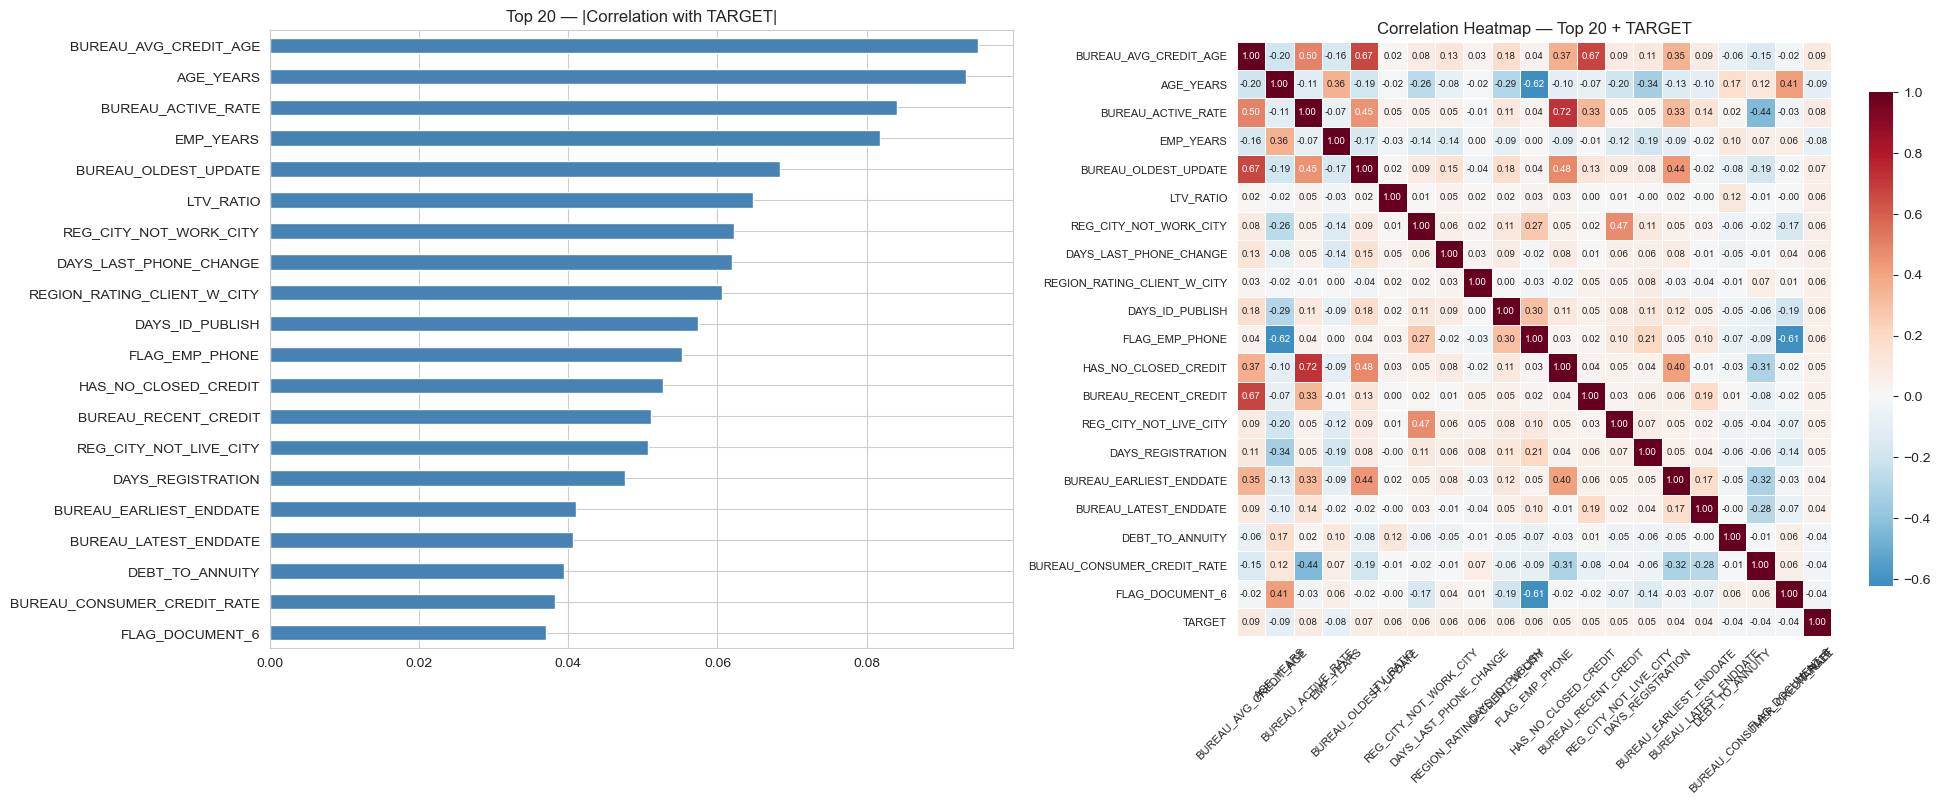

In [36]:
# Heatmap — top-20 TARGET-correlated features
top20 = target_corr_abs.head(20).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bar chart
target_corr_abs.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 — |Correlation with TARGET|')
axes[0].invert_yaxis()

# Heatmap
sns.heatmap(merged_df_reduced[top20 + ['TARGET']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Heatmap — Top 20 + TARGET')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

Columns with outliers: 16 / 28


,column,total,outlier_count,outlier_pct,lower_bound,upper_bound,min,max
17,BUREAU_MAX_AMT_OVERDUE,146768,35428,24.14,-272.30,363.06,0.00,94812246.00
15,BUREAU_LATEST_ENDDATE,145476,23828,16.38,-4581.00,6304.00,-2858.00,31199.00
22,BUREAU_DEBT_UTIL,104798,12092,11.54,5.00,5.00,0.00,5.00
19,BUREAU_MEAN_DEBT,146768,7194,4.90,-343955.60,458607.46,-684441.18,33902743.50
18,BUREAU_MAX_CREDIT,146768,7192,4.90,-1595475.00,2494800.00,0.00,135000000.00
12,BUREAU_RECENT_CREDIT,146768,4908,3.34,-2087.00,1322.00,-2922.00,0.00
9,EMP_YEARS,137453,2255,1.64,-18.30,29.30,0.00,46.10
1,AMT_INCOME_TOTAL,173647,1805,1.04,-126000.00,409500.00,25650.00,117000000.00
14,BUREAU_EARLIEST_ENDDATE,145476,1494,1.03,-7215.00,4643.00,-4736.00,31198.00
16,BUREAU_LATEST_CLOSED,127683,1101,0.86,-2461.00,1578.00,-2887.00,0.00


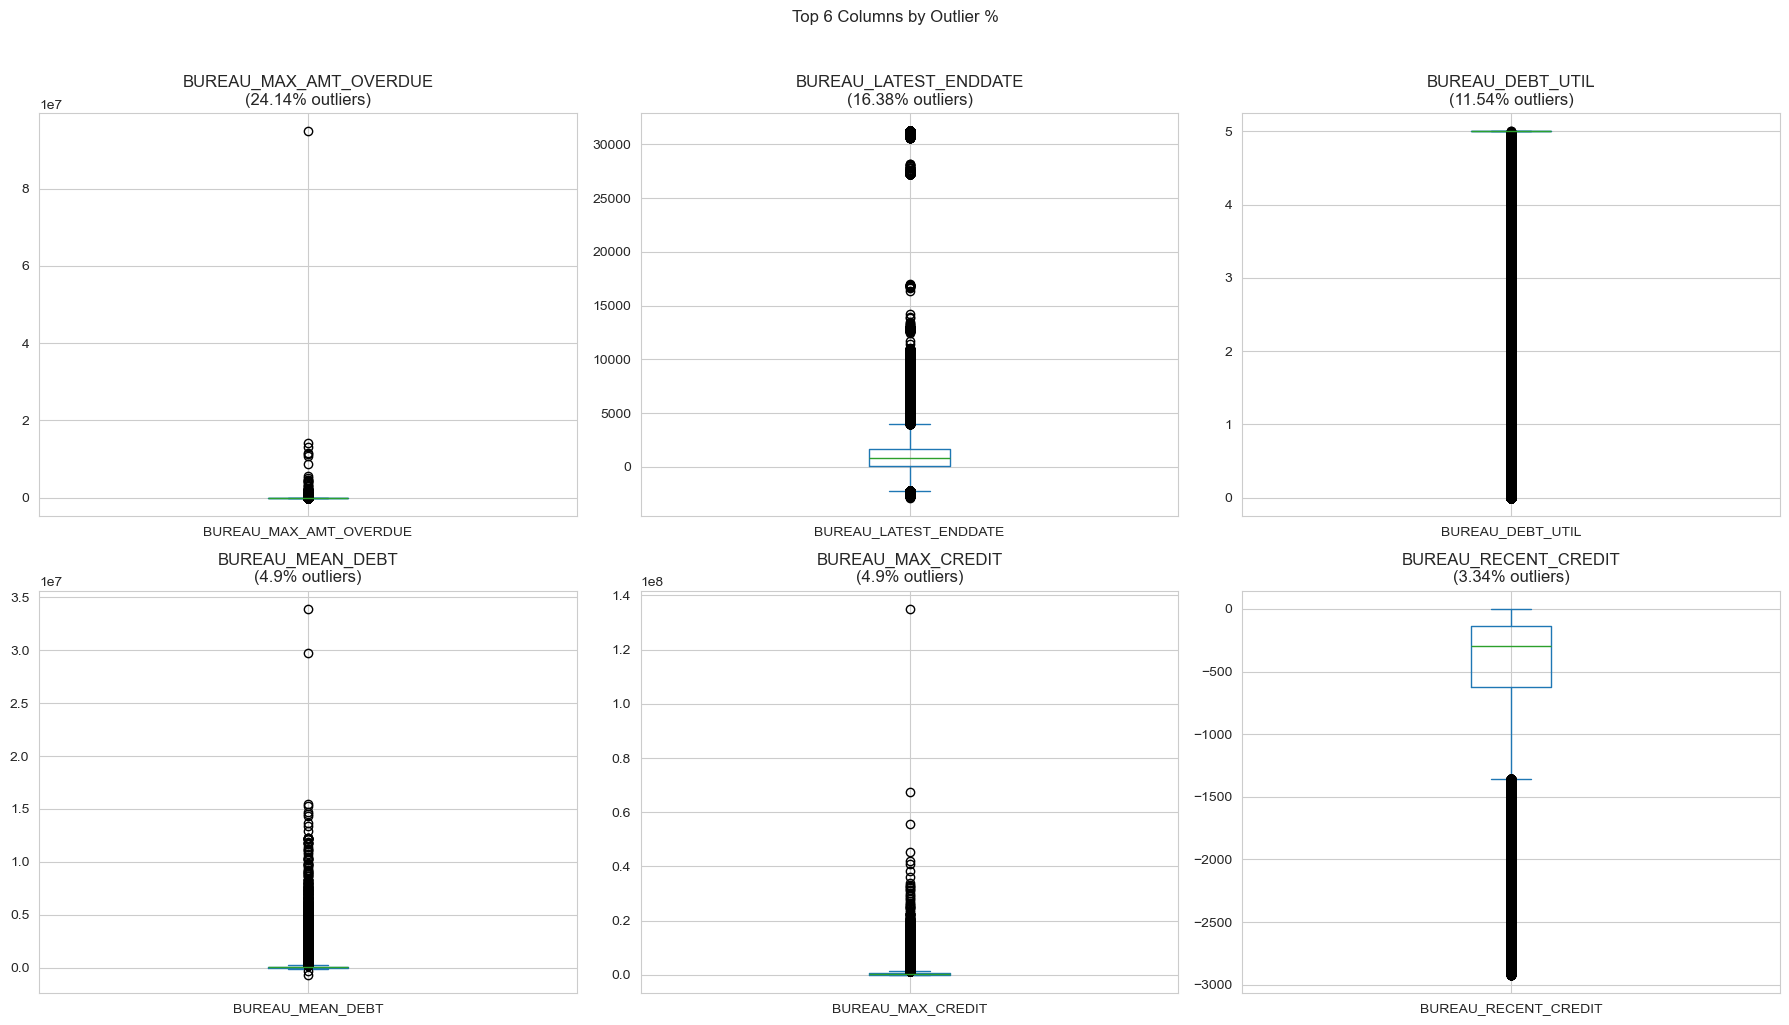


=== PROPOSED OUTLIER TREATMENT ===
Valid outliers (domain-expected extreme values):
  - AMT_INCOME_TOTAL: high incomes are valid → cap at 99th pctile
  - DAYS_EMPLOYED: 365243 placeholder already replaced with NaN
  - CNT_CHILDREN: large families valid → cap at 5+
Invalid outliers (likely data errors):
  - Negative values in amount fields → flag for review
  - Illogical DAYS values → review and treat


In [38]:
# Outlier detection — IQR method
num_cols_eda = merged_df_reduced.select_dtypes(include='number').columns.tolist()
# Skip zero-inflated columns from outlier capping
# A column is zero-inflated if its 75th percentile is 0
zero_inflated = [col for col in num_cols_eda 
                 if merged_df_reduced[col].quantile(0.75) == 0]
num_cols_eda = [c for c in num_cols_eda 
                if c not in ['SK_ID_CURR', 'TARGET']
                and c not in zero_inflated
                and merged_df_reduced[c].nunique() > 10]

outlier_rows = []
for col in num_cols_eda:
    data = merged_df_reduced[col].dropna()
    if len(data) == 0:
        continue
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_rows.append({
        'column': col,
        'total': len(data),
        'outlier_count': n_out,
        'outlier_pct': round(n_out / len(data) * 100, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'min': round(data.min(), 2),
        'max': round(data.max(), 2),
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
print(f"Columns with outliers: "
      f"{(outlier_df['outlier_count'] > 0).sum()} / {len(outlier_df)}")
display(outlier_df.head(30))

# Box-plots for top-6 outlier columns
top6 = outlier_df.head(6)['column'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(top6):
    ax = axes[i // 3, i % 3]
    merged_df_reduced[col].dropna().plot(kind='box', ax=ax)
    pct = outlier_df.loc[outlier_df['column'] == col, 'outlier_pct'].values[0]
    ax.set_title(f'{col}\n({pct}% outliers)')
plt.suptitle('Top 6 Columns by Outlier %', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== PROPOSED OUTLIER TREATMENT ===")
print("Valid outliers (domain-expected extreme values):")
print("  - AMT_INCOME_TOTAL: high incomes are valid → cap at 99th pctile")
print("  - DAYS_EMPLOYED: 365243 placeholder already replaced with NaN")
print("  - CNT_CHILDREN: large families valid → cap at 5+")
print("Invalid outliers (likely data errors):")
print("  - Negative values in amount fields → flag for review")
print("  - Illogical DAYS values → review and treat")

In [37]:
##final shape before WOE
merged_df_reduced.shape

(173647, 80)